In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
korean_font = next((f for f in font_candidates if f in available_fonts), None)

if korean_font:
    plt.rcParams["font.family"] = korean_font
    plt.rcParams["font.sans-serif"] = [korean_font] + plt.rcParams["font.sans-serif"]
else:
    print("한글 폰트를 찾지 못했습니다. '맑은 고딕' 또는 '나눔고딕'을 설치한 뒤 커널을 재시작하세요.")

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

In [2]:
import pandas as pd

df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


결측치 없음

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`의 최솟값이 0이다.

`Pregnancies`를 제외한 나머지 컬럼은 0이 나올 수 없는 값이므로 사실상 결측치나 다름 없다고 추측할 수 있다.

In [5]:
zero_like_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = pd.DataFrame({
    "0으로 기록된 행(명)": (df[zero_like_cols] == 0).sum(),
    "비율(%)": ((df[zero_like_cols] == 0).mean() * 100).round(1),
})
display(zero_counts)

,0으로 기록된 행(명),비율(%)
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


다음으로 라벨의 비율을 한번 살펴봅시다.

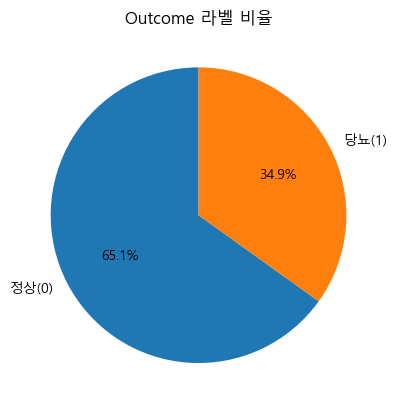

In [6]:
import matplotlib.pyplot as plt

outcome_counts = df['Outcome'].value_counts().sort_index()
labels = ["정상(0)", "당뇨(1)"]

plt.pie(outcome_counts, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Outcome 라벨 비율")
plt.show()

당뇨 환자보다 정상의 비율이 2배 가량 높은 것을 확인할 수 있다.

변수 간의 상관관계를 확인해 봅시다.

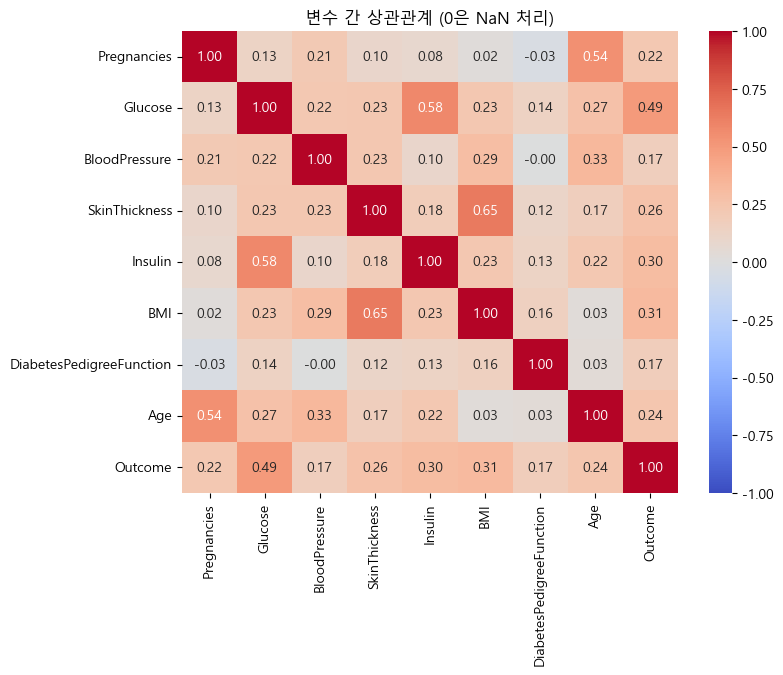

In [7]:
import numpy as np
import seaborn as sns

zero_like_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_corr = df.copy()
df_corr[zero_like_cols] = df_corr[zero_like_cols].replace(0, np.nan)

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("변수 간 상관관계 (0은 NaN 처리)")
plt.show()

상관관계가 0.4 이상인 컬럼들만 출력해 보고, 산점도를 그려본다.

In [8]:
import numpy as np

corr_matrix = df_corr.corr()
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

strong_corr = corr_matrix.where(mask & (corr_matrix.abs() >= 0.4)).stack()
strong_corr = strong_corr.sort_values(ascending=False)

print(strong_corr)

SkinThickness  BMI        0.648214
Glucose        Insulin    0.581186
Pregnancies    Age        0.544341
Glucose        Outcome    0.494650
dtype: float64


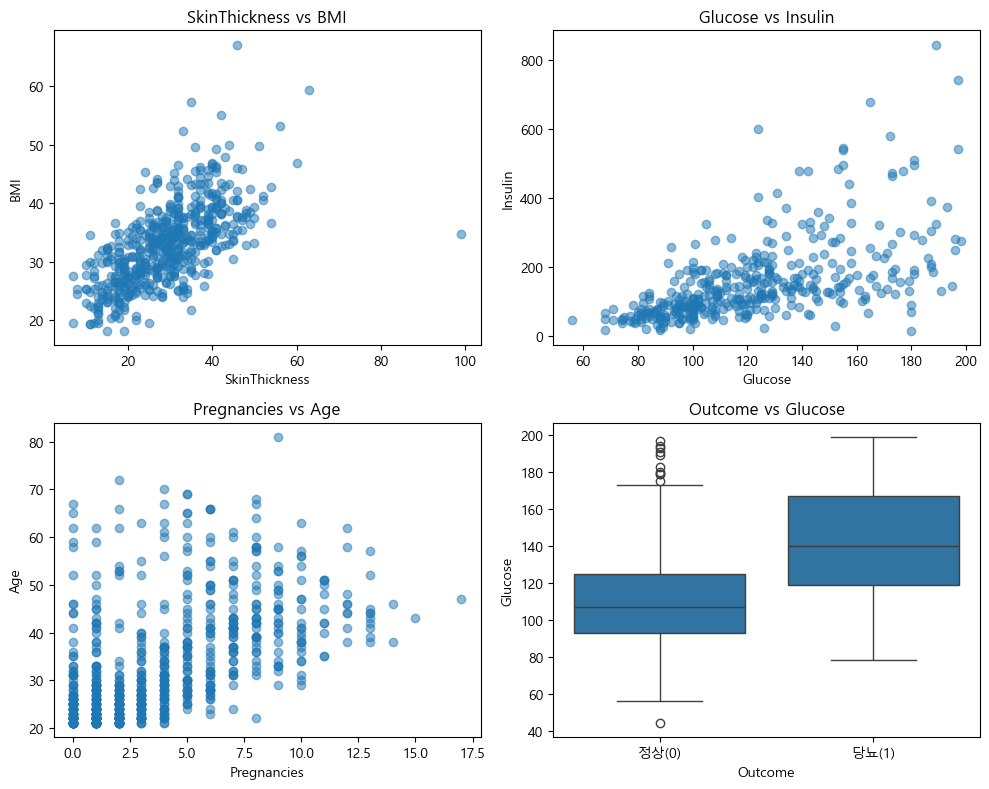

In [9]:
pairs = [
    ("SkinThickness", "BMI"),
    ("Glucose", "Insulin"),
    ("Pregnancies", "Age"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (x, y) in zip(axes.flatten(), pairs):
    ax.scatter(df_corr[x], df_corr[y], alpha=0.5)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

sns.boxplot(data=df_corr, x="Outcome", y="Glucose", ax=axes[1, 1])
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["정상(0)", "당뇨(1)"])
axes[1, 1].set_title("Outcome vs Glucose")

plt.tight_layout()
plt.show()

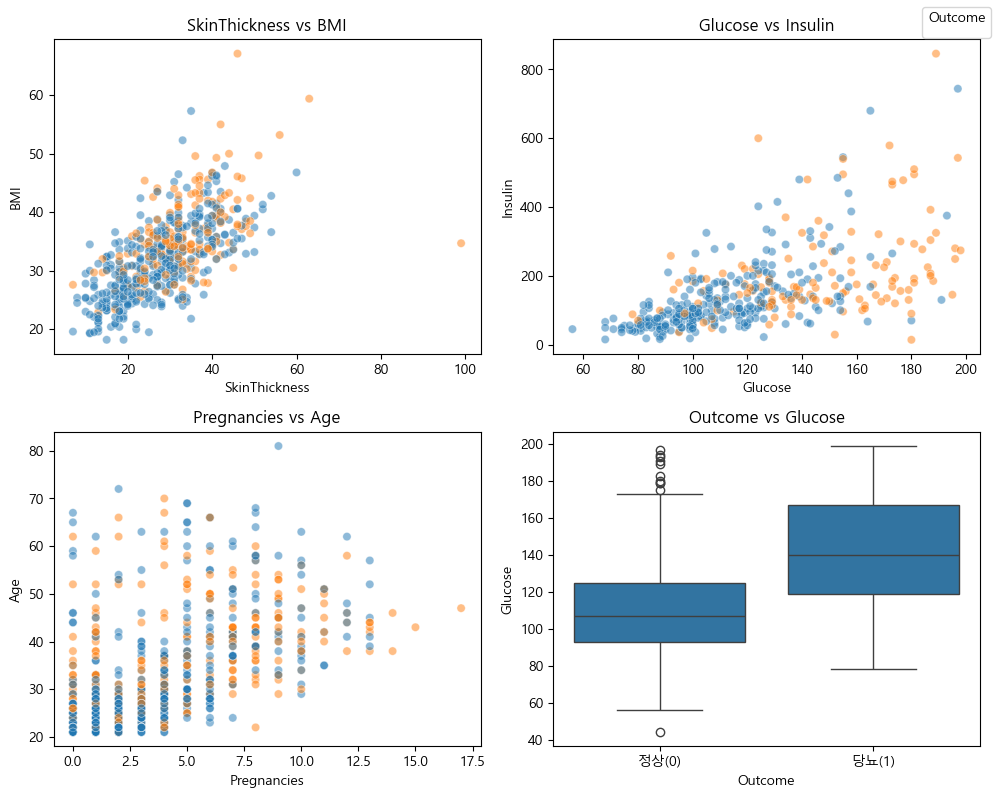

In [10]:
pairs = [
    ("SkinThickness", "BMI"),
    ("Glucose", "Insulin"),
    ("Pregnancies", "Age"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (x, y) in zip(axes.flatten(), pairs):
    sns.scatterplot(data=df_corr, x=x, y=y, hue="Outcome", alpha=0.5, ax=ax, legend=False)
    ax.set_title(f"{x} vs {y}")

sns.boxplot(data=df_corr, x="Outcome", y="Glucose", ax=axes[1, 1])
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["정상(0)", "당뇨(1)"])
axes[1, 1].set_title("Outcome vs Glucose")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ["정상(0)", "당뇨(1)"], loc="upper right", title="Outcome")

plt.tight_layout()
plt.show()


이번엔 이상치를 확인해 보자. 각 컬럼 값들의 박스 플롯을 그려보면,

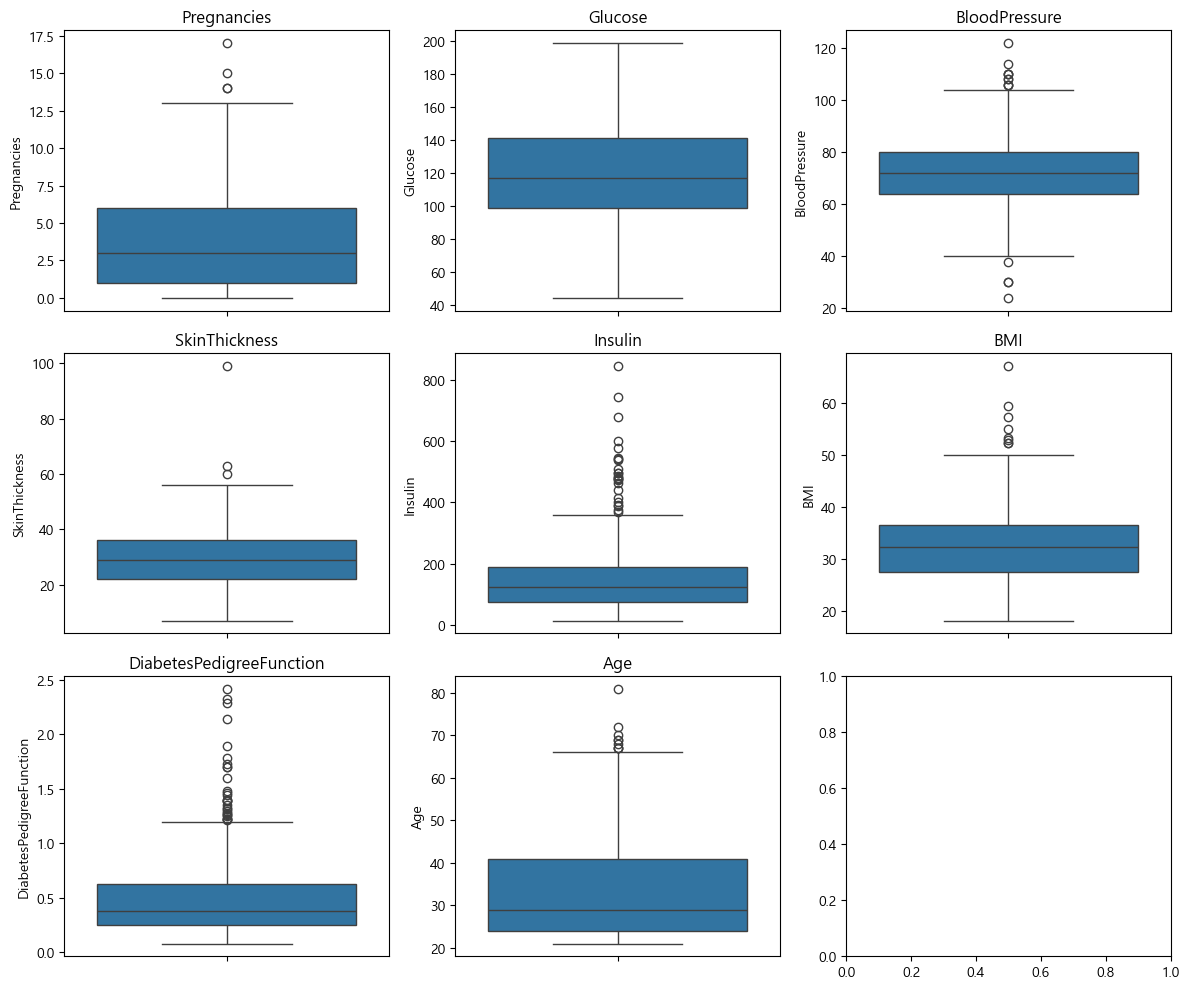

In [12]:
cols = df_corr.columns.drop("Outcome")

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(y=df_corr[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


이상치가 정상적인 값인지, 혹은 이상치 자체가 당뇨병 여부와 연관이 있는지도 확인해 봅시다.

마찬가지로 0인 데이터도 이상치이기 때문에 별도로 확인해 보도록 하겠습니다.

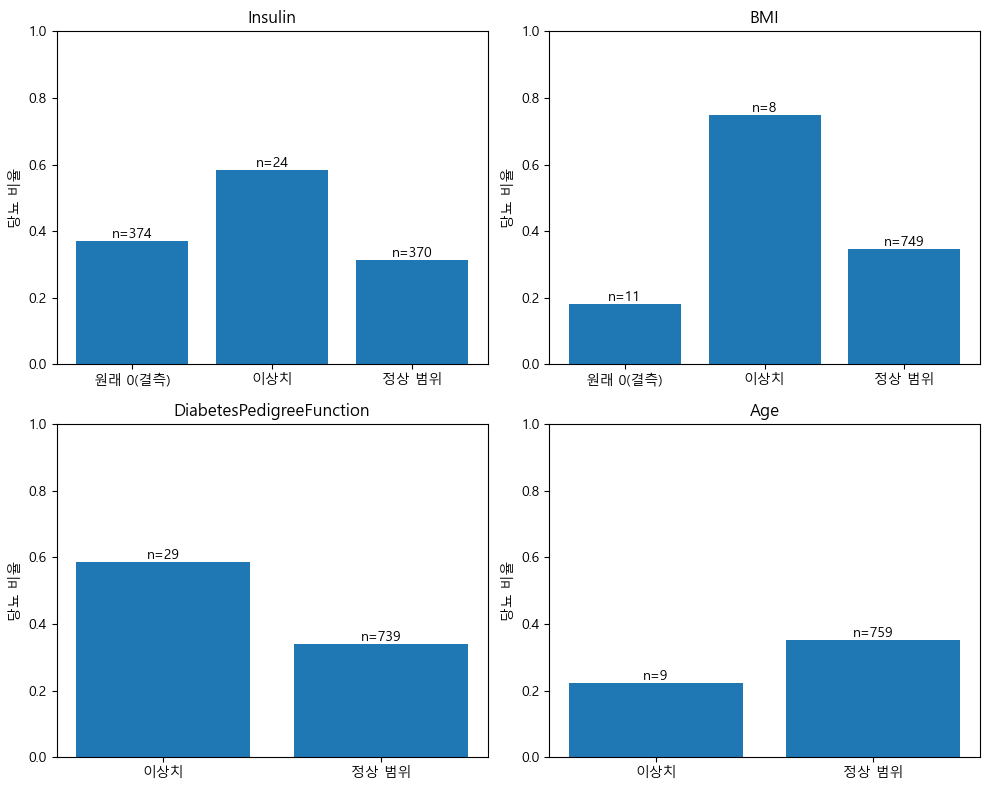

In [13]:
zero_like_cols = ["Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, col in zip(axes.flatten(), zero_like_cols):
    is_missing = df[col] == 0

    q1, q3 = df_corr[col].quantile(0.25), df_corr[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_outlier = (df_corr[col] < lower) | (df_corr[col] > upper)

    group = pd.Series("정상 범위", index=df.index)
    group[is_outlier] = "이상치"
    group[is_missing] = "원래 0(결측)"

    ratio = df.groupby(group)["Outcome"].mean()
    count = df.groupby(group)["Outcome"].size()

    bars = ax.bar(ratio.index, ratio.values)
    for bar, n in zip(bars, count.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"n={n}", ha="center", va="bottom")

    ax.set_ylim(0, 1)
    ax.set_ylabel("당뇨 비율")
    ax.set_title(col)

plt.tight_layout()
plt.show()

이쯤에서 한번 베이스 모델을 돌려 보도록 하겠습니다. 선형 모델과 트리 기반 모델은 데이터를 처리하는 방식이 다르기 때문에 이쯤에서 둘 다 테스트 해보고, 더 좋은 성능을 보이는 모델 계열로 진행해 보도록 하겠습니다.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

X = df.drop(columns="Outcome")
y = df["Outcome"]

# stratify=y 옵션으로 라벨 비율 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

linear_model = LogisticRegression(max_iter=1000)
linear_model.fit(X_train, y_train)

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {"linear_model": linear_model, "tree_model": tree_model}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"[{name}]")
    print(f"accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"precision: {precision_score(y_test, y_pred):.3f}")
    print(f"recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"f1 score : {f1_score(y_test, y_pred):.3f}")
    print(f"auc      : {roc_auc_score(y_test, y_proba):.3f}")
    print()


[linear_model]
accuracy : 0.714
precision: 0.609
recall   : 0.519
f1 score : 0.560
auc      : 0.823

[tree_model]
accuracy : 0.727
precision: 0.643
recall   : 0.500
f1 score : 0.562
auc      : 0.675



`tree_model`의 auc가 굉장히 낮게 나오는데, 이는 과적합의 신호로 해석해볼 수 있습니다. 한 번 직접 훈련셋에 대한 정확도도 출력해 보겠습니다.

In [16]:
from sklearn.metrics import roc_auc_score, accuracy_score

# 1) 과적합 여부 확인: train vs test 성능 비교
train_pred = tree_model.predict(X_train)
train_proba = tree_model.predict_proba(X_train)[:, 1]

print("[tree_model] train vs test")
print(f"train accuracy: {accuracy_score(y_train, train_pred):.3f} / test accuracy: {accuracy_score(y_test, tree_model.predict(X_test)):.3f}")
print(f"train auc     : {roc_auc_score(y_train, train_proba):.3f} / test auc     : {roc_auc_score(y_test, tree_model.predict_proba(X_test)[:, 1]):.3f}")
print()

[tree_model] train vs test
train accuracy: 1.000 / test accuracy: 0.727
train auc     : 1.000 / test auc     : 0.675



훈련셋에 대한 정확도와 auc가 모두 1.000이라는 것은 답을 외웠다는 것입니다. 전형적인 과적합의 형태입니다. 트리의 깊이(max_depth)에 제한을 주고 다시 비교해 보도록 하겠습니다.

In [17]:
tree_model_shallow = DecisionTreeClassifier(random_state=42, max_depth=4)
tree_model_shallow.fit(X_train, y_train)

models = {"linear_model": linear_model, "tree_model": tree_model_shallow}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"[{name}]")
    print(f"accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"precision: {precision_score(y_test, y_pred):.3f}")
    print(f"recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"f1 score : {f1_score(y_test, y_pred):.3f}")
    print(f"auc      : {roc_auc_score(y_test, y_proba):.3f}")
    print()


[linear_model]
accuracy : 0.714
precision: 0.609
recall   : 0.519
f1 score : 0.560
auc      : 0.823

[tree_model]
accuracy : 0.799
precision: 0.745
recall   : 0.648
f1 score : 0.693
auc      : 0.792



auc를 제외한 지표들은 tree_model이 더 높게 나타나고 있습니다. 객관적인 평가를 위해 k-fold cross validation까지 적용해 보겠습니다.

In [18]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

models = {
    "linear_model": LogisticRegression(max_iter=1000),
    "tree_model_shallow": DecisionTreeClassifier(max_depth=4, random_state=42),
}

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    print(f"[{name}]")
    for metric in scoring:
        print(f"{metric:10s}: {scores['test_' + metric].mean():.3f}")
    print()


[linear_model]
accuracy  : 0.771
precision : 0.724
recall    : 0.567
f1        : 0.633
roc_auc   : 0.830

[tree_model_shallow]
accuracy  : 0.738
precision : 0.626
recall    : 0.657
f1        : 0.634
roc_auc   : 0.790



보면 linear_model은 precision 수치(모델이 당뇨로 예측한 사람들 중 실제로 당뇨인 사람의 비율)가 더 높고, tree_model은 recall 수치(실제 당뇨 환자를 모델이 당뇨라고 제대로 잡아낸 비율)가 더 높습니다.

이 경우에는 상황에 따라 다를 수 있지만, 여기선 당뇨병을 정상인이라고 잘못 예측하는 것이 더 치명적이라고 판단하여 recall 수치가 높은 tree model로 이어 가보도록 하겠습니다.

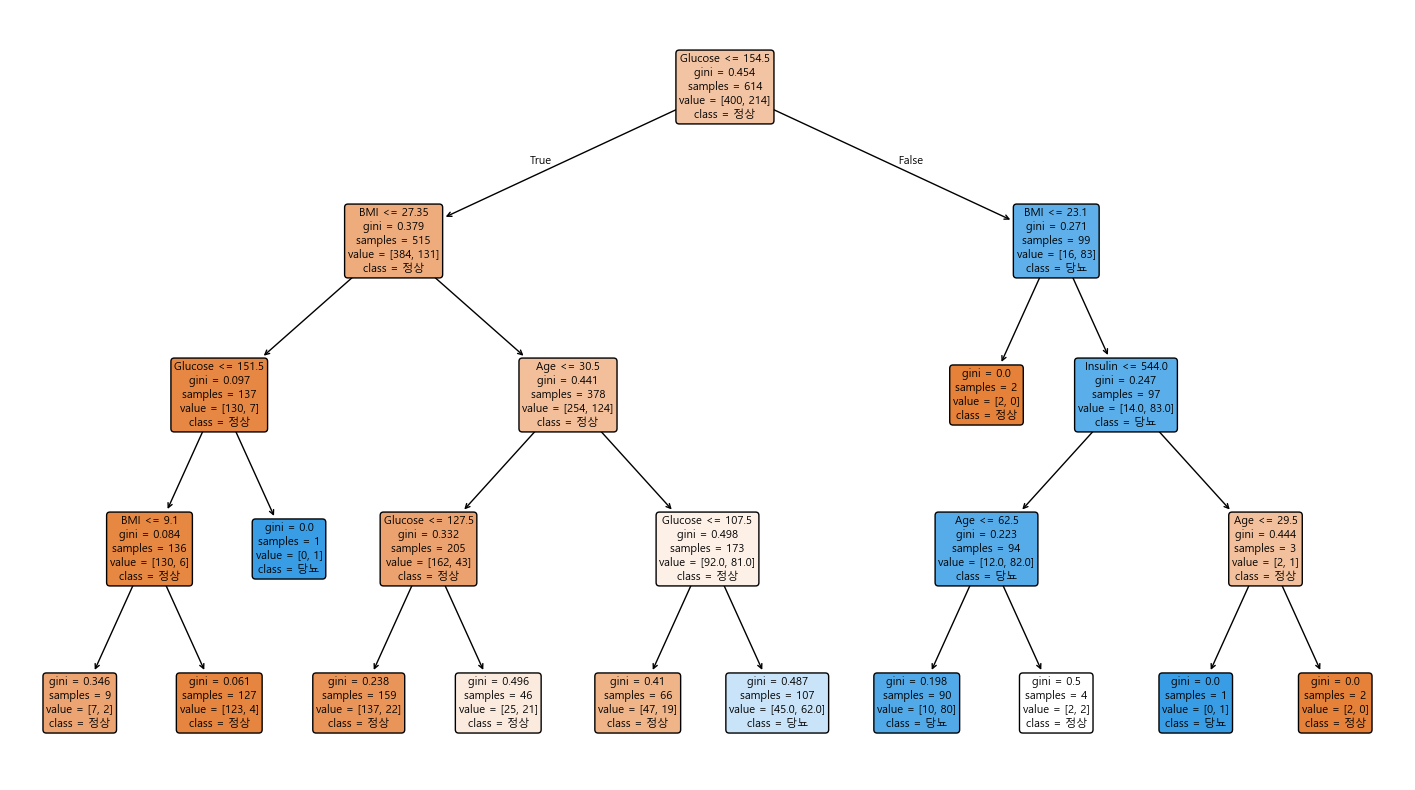

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(tree_model_shallow, feature_names=X.columns, class_names=["정상", "당뇨"], filled=True, rounded=True, fontsize=8)
plt.show()

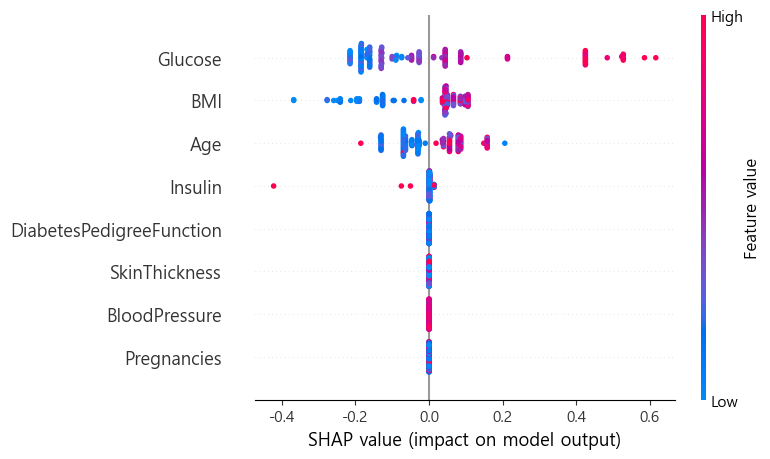

In [20]:
import shap

explainer = shap.TreeExplainer(tree_model_shallow)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:, :, 1], X_test)

* 0값 처리 — 지금 모델 학습(X = df.drop(columns="Outcome"))에는 0이 그대로 들어가 있는데, Insulin은 48.7%, SkinThickness는 29.6%가 0(=사실상 결측)이었죠. 상관관계 볼 때는 NaN 처리했지만 모델에는 반영 안 됐어요. median 대체나 "원래 0이었는지" 표시하는 플래그 컬럼을 추가해보면 트리가 왜곡된 값(0)을 실제 패턴으로 오해하는 걸 줄일 수 있을지 시험해볼 만합니다.

In [23]:
zero_like_cols = ["Insulin", "SkinThickness", "Glucose", "BloodPressure", "BMI"]

eval_df = X_test.copy()
eval_df["실제"] = y_test
eval_df["예측"] = tree_model_shallow.predict(X_test)
eval_df["정답여부"] = (eval_df["실제"] == eval_df["예측"])

for col in zero_like_cols:
    has_zero = eval_df[col] == 0
    acc_zero = eval_df.loc[has_zero, "정답여부"].mean()
    acc_nonzero = eval_df.loc[~has_zero, "정답여부"].mean()
    n_zero = has_zero.sum()
    print(f"{col:15s} | 0값 정답률: {acc_zero:.3f} (n={n_zero}) | 정상값 정답률: {acc_nonzero:.3f}")


Insulin         | 0값 정답률: 0.786 (n=84) | 정상값 정답률: 0.814
SkinThickness   | 0값 정답률: 0.788 (n=52) | 정상값 정답률: 0.804
Glucose         | 0값 정답률: 1.000 (n=1) | 정상값 정답률: 0.797
BloodPressure   | 0값 정답률: 0.833 (n=12) | 정상값 정답률: 0.796
BMI             | 0값 정답률: 1.000 (n=2) | 정상값 정답률: 0.796


비록 0인 값들에 대한 정답률 자체가 크게 떨어지진 않고 있지만, 0 자체는 결측치와 같기 때문에 처리를 하는 것이 맞습니다.

In [24]:
zero_like_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = pd.DataFrame({
    "0으로 기록된 행(명)": (df[zero_like_cols] == 0).sum(),
    "비율(%)": ((df[zero_like_cols] == 0).mean() * 100).round(1),
})
display(zero_counts)

,0으로 기록된 행(명),비율(%)
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


여기서는 결측으로 보는 5개 항목의 0을 모두 처리합니다. 첫 번째는 모두 중앙값으로 채우고, 두 번째는 SkinThickness와 Insulin만 다른 항목을 이용한 선형회귀로 채웁니다. 나머지 3개 항목은 두 방법 모두 중앙값으로 채웁니다.

우선 결측이 많은 SkinThickness와 Insulin의 분포를 살펴보겠습니다. 평균과 중앙값이 얼마나 다른지 확인해 봅시다.

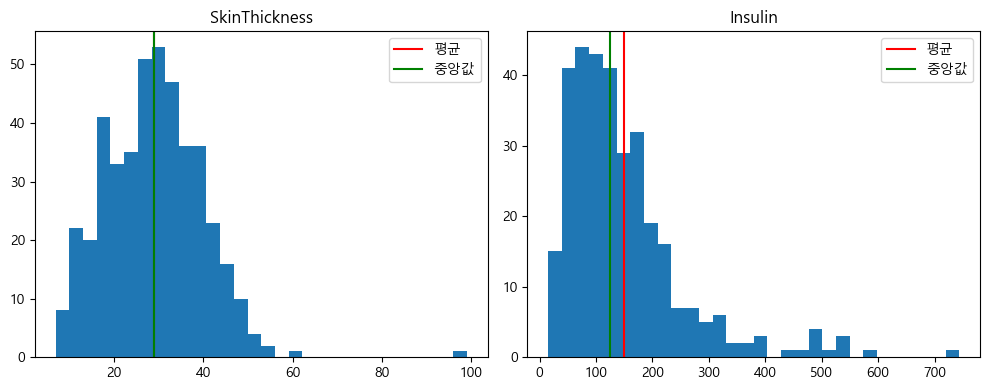

In [31]:
train_observed = X_train.copy()

missing_cols = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]
train_observed[missing_cols] = (
    train_observed[missing_cols].replace(0, np.nan)
)

cols = ["SkinThickness", "Insulin"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, cols):
    ax.hist(train_observed[col].dropna(), bins=30)
    ax.axvline(train_observed[col].mean(), color="red", label="평균")
    ax.axvline(train_observed[col].median(), color="green", label="중앙값")
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

SkinThickness는 평균과 중앙값이 가깝고, Insulin은 큰 값 쪽으로 꼬리가 길어 두 값에 차이가 있습니다. 큰 값의 영향을 덜 받는 중앙값 대체를 첫 비교 기준으로 삼겠습니다.

중앙값은 교차검증의 각 학습 부분에서만 계산합니다. 처리 전 모델은 데이터 점검을 위한 참고로 두고, 이후에는 결측을 처리한 방법끼리 비교합니다.

In [32]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

zero_like_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

X_nan = X.copy()
X_nan[zero_like_cols] = X_nan[zero_like_cols].replace(0, np.nan)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42)),
])

# 결측 처리 방법 비교의 기준: 5개 항목 모두 중앙값 대체
scores_imputed = cross_validate(pipeline, X_nan, y, cv=cv, scoring=scoring)
print("[중앙값 대체 후]")
for metric in scoring:
    print(f"{metric:10s}: {scores_imputed['test_' + metric].mean():.3f}")

[중앙값 대체 후]
accuracy  : 0.728
precision : 0.612
recall    : 0.638
f1        : 0.617
roc_auc   : 0.768


다음은 SkinThickness를 BMI로, Insulin을 Glucose로 예측해 채우는 방법입니다. 앞에서 관찰한 두 항목 사이의 관계를 이용하되, 실제 측정값을 복원한다고 보장할 수는 없습니다.

먼저 Glucose·BloodPressure·BMI의 0을 각 학습 부분의 중앙값으로 채웁니다. 그 뒤 SkinThickness·Insulin의 관측값으로 회귀식을 학습해 해당 항목의 0을 채웁니다. 이 순서로 회귀 예측에 사용하는 BMI나 Glucose에도 0이 남지 않게 합니다.

실행 점검에서 회귀식이 Insulin 결측값을 음수로 예측한 기록이 있었습니다. 회귀 예측값이 0 이하이면 해당 학습 부분의 관측값 중앙값으로 채웁니다. 원래 관측된 큰 값이나 작은 값은 이 규칙으로 바꾸지 않습니다.

In [38]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression

class ZeroMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self, columns=("Glucose", "BloodPressure", "BMI")):
        self.columns = columns

    def fit(self, X, y=None):
        values = X[list(self.columns)].replace(0, np.nan)
        self.imputer_ = SimpleImputer(strategy="median").fit(values)
        return self

    def transform(self, X):
        X = X.copy()
        cols = list(self.columns)
        X[cols] = self.imputer_.transform(X[cols].replace(0, np.nan))
        return X

class RegressionImputer(BaseEstimator, TransformerMixin):
    def __init__(self, target_col, predictor_col):
        self.target_col = target_col
        self.predictor_col = predictor_col

    def fit(self, X, y=None):
        valid = (X[self.target_col] != 0) & (X[self.predictor_col] != 0)
        self.fallback_ = X.loc[X[self.target_col] > 0, self.target_col].median()
        self.reg_ = LinearRegression()
        self.reg_.fit(X.loc[valid, [self.predictor_col]], X.loc[valid, self.target_col])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.target_col] = X[self.target_col].astype(float)
        missing = X[self.target_col] == 0
        if missing.any():
            predicted = self.reg_.predict(X.loc[missing, [self.predictor_col]])
            X.loc[missing, self.target_col] = np.where(predicted > 0, predicted, self.fallback_)
        return X

pipeline = Pipeline([
    ("impute_other", ZeroMedianImputer()),
    ("impute_skin", RegressionImputer("SkinThickness", "BMI")),
    ("impute_insulin", RegressionImputer("Insulin", "Glucose")),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42)),
])

scores_regression = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)

print(f"{'지표':10s} | {'중앙값 대체':>10s} | {'회귀 대체':>10s}")
for metric in scoring:
    m = scores_imputed["test_" + metric].mean()
    r = scores_regression["test_" + metric].mean()
    print(f"{metric:10s} | {m:10.3f} | {r:10.3f}")

지표         |     중앙값 대체 |      회귀 대체
accuracy   |      0.728 |      0.736
precision  |      0.612 |      0.614
recall     |      0.638 |      0.661
f1         |      0.617 |      0.635
roc_auc    |      0.768 |      0.761


대체로 지표가 높은 회귀 대체 방식을 사용하도록 하겠습니다.

여기서 그치지 말고, 모델이 중요하게 본 변수들 (Glucose, BMI, Age) 중에서 모델이 어떤 데이터를 틀리는 지를 먼저 확인해 봅시다.

당뇨가 있는 환자들 데이터들을 각 변수 들로 묶어서 보고, 모델이 틀린 사람과 맞춘 사람들의 변수 분포를 박스 플롯으로 확인해 봅니다.

결과
맞춤(TP)    35
놓침(FN)    19
Name: count, dtype: int64


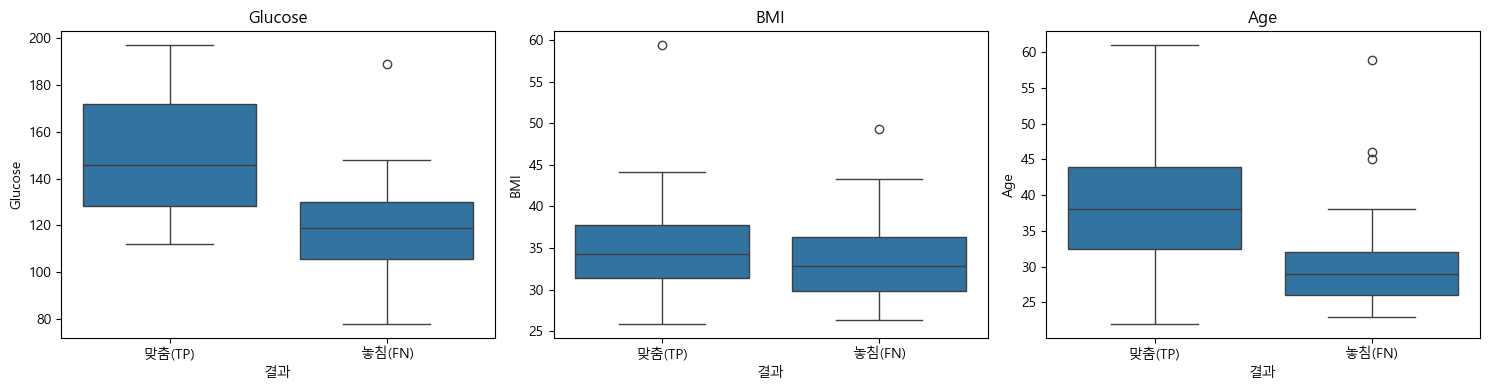

In [39]:
result_df = X_test.copy()
result_df["실제"] = y_test
result_df["예측"] = tree_model_shallow.predict(X_test)

actual_positive = result_df[result_df["실제"] == 1].copy()
actual_positive["결과"] = np.where(actual_positive["예측"] == 1, "맞춤(TP)", "놓침(FN)")

check_cols = ["Glucose", "BMI", "Age"]  # SHAP에서 상위로 나온 변수로 교체

fig, axes = plt.subplots(1, len(check_cols), figsize=(5 * len(check_cols), 4))
for ax, col in zip(axes, check_cols):
    sns.boxplot(data=actual_positive, x="결과", y=col, ax=ax)
    ax.set_title(col)

print(actual_positive["결과"].value_counts())
plt.tight_layout()
plt.show()

이걸 보면 Glucose랑 Age가 낮은데 당뇨인 사람들을 모델이 잘 놓치는 것을 볼 수 있습니다. 이 두 변수를 기준으로 모델이 실제로 어디서 틀리는지 눈으로 확인해 보도록 하겠습니다.

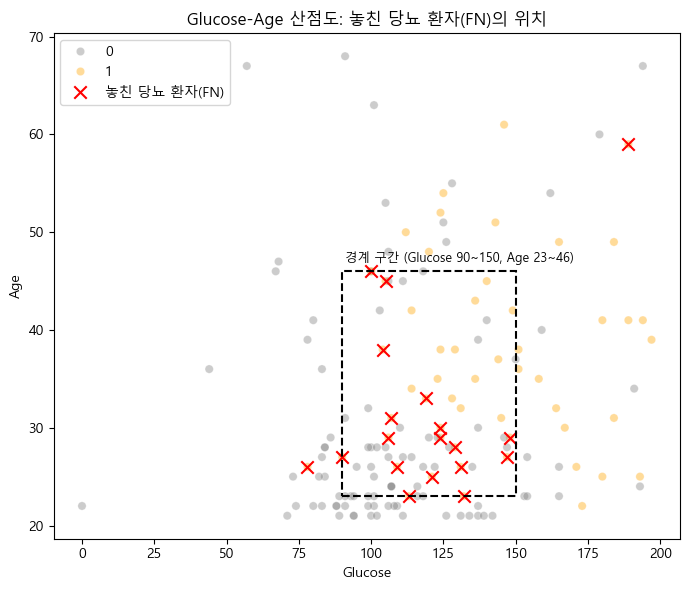

In [ ]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(7, 6))

sns.scatterplot(
    data=result_df, x="Glucose", y="Age", hue="실제",
    palette={0: "gray", 1: "orange"}, alpha=0.4, ax=ax
)

fn_points = actual_positive[actual_positive["결과"] == "놓침(FN)"]
ax.scatter(
    fn_points["Glucose"], fn_points["Age"],
    color="red", marker="x", s=80, label="놓친 당뇨 환자(FN)"
)

# Glucose·Age가 애매하게 겹치는 경계 구간
ax.add_patch(Rectangle(
    (90, 23), 150 - 90, 46 - 23,
    fill=False, edgecolor="black", linestyle="--", linewidth=1.5
))
ax.text(91, 47, "경계 구간 (Glucose 90~150, Age 23~46)", fontsize=9)

ax.set_title("Glucose-Age 산점도: 놓친 당뇨 환자(FN)의 위치")
ax.legend()
plt.tight_layout()
plt.show()

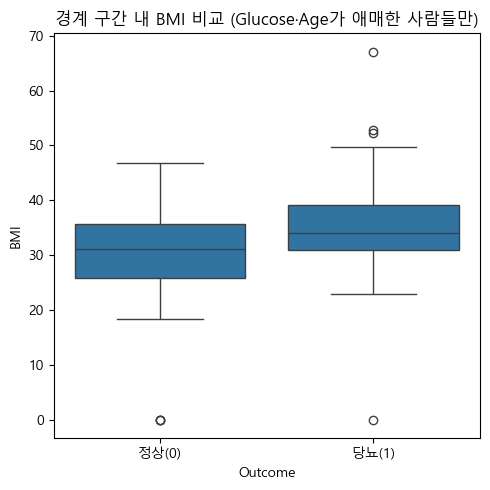

In [40]:
# 경계 구간 안 사람들만 추려서, BMI가 실제/정상 여부를 가르는지 확인
box_region = df[(df["Glucose"].between(90, 150)) & (df["Age"].between(23, 46))]

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=box_region, x="Outcome", y="BMI", ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["정상(0)", "당뇨(1)"])
ax.set_title("경계 구간 내 BMI 비교 (Glucose·Age가 애매한 사람들만)")
plt.tight_layout()
plt.show()


현재 트리 모델은 Glucose를 기준으로 구분을 하고, 그 안에서 다시 BMI를 기준으로 나누는 식으로 두 변수를 순차적으로 조합해서 보고 있습니다.

그렇다 보니 지금 저희가 보고 있는 이 좁은 경계 구간 안에서 BMI까지 높은 사람만 골라내려면 또 한 번의 분기가 필요한데, 현재 트리에서 그 조합까지 표현할 여유가 부족합니다.

따라서 곱 항(Glucose x BMI 또는 Age x BMI)을 미리 만들어 주면, 모델이 Glucose도 크고 BMI도 큰 경우라는 조건을 분기 한번으로 바로 표현할 수 있게 해줄 수 있습니다.